In [2]:
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from huggingface_hub import HfApi

import pandas as pd
import torch
import numpy as np

# Download

In [8]:
path_csv = hf_hub_download(
    "hyunnnnnnnn/rxrx3_smiles_embedding",
    "rxrx3_smiles_embeddings.csv",
    local_dir="./",
    repo_type="dataset"
)
path_parquet = hf_hub_download(
    "hyunnnnnnnn/rxrx3_smiles_embedding",
    "rxrx3_smiles_embeddings.parquet",
    local_dir="./",
    repo_type="dataset"
)
path_pt = hf_hub_download(
    "hyunnnnnnnn/rxrx3_smiles_embedding",
    "rxrx3_smiles_embeddings.pt",
    local_dir="./",
    repo_type="dataset"
)

print(path_csv)
print(path_parquet)
print(path_pt)
# df_csv = pd.read_csv(path_csv)
# df_parquet = pd.read_parquet(path_parquet)

rxrx3_smiles_embeddings.pt:   0%|          | 0.00/103M [00:00<?, ?B/s]

rxrx3_smiles_embeddings.csv
rxrx3_smiles_embeddings.parquet
rxrx3_smiles_embeddings.pt


# Check data

In [3]:
df = pd.read_csv("./rxrx3_smiles_embeddings.csv")
df.head()

,well_id,experiment_name,plate,address,gene,treatment,SMILES,concentration,perturbation_type,cell_type,...,feature_375,feature_376,feature_377,feature_378,feature_379,feature_380,feature_381,feature_382,feature_383,SMILES_nometa
0,compound-003_11_AD37,compound-003,11,AD37,NaN,Phloretin,"OC1=CC=C(CCC(=O)C2=C(O)C=C(O)C=C2O)C=C1 |c:9,1...",0.0250,COMPOUND,HUVEC,...,-0.162979,0.054389,-0.069481,-0.124423,0.022028,0.022953,-0.079113,0.173631,-0.128588,OC1=CC=C(CCC(=O)C2=C(O)C=C(O)C=C2O)C=C1
1,compound-003_35_Y15,compound-003,35,Y15,NaN,Clozapine,CN1CCN(CC1)C1=NC2=C(NC3=C1C=CC=C3)C=CC(Cl)=C2 ...,2.5000,COMPOUND,HUVEC,...,-0.176950,0.068680,-0.112014,-0.106931,-0.081489,0.027819,-0.096354,0.191950,-0.200426,CN1CCN(CC1)C1=NC2=C(NC3=C1C=CC=C3)C=CC(Cl)=C2
2,compound-001_19_D20,compound-001,19,D20,NaN,Dequalinium,CC1=[N+](CCCCCCCCCC[N+]2=C(C)C=C(N)C3=CC=CC=C2...,0.2500,COMPOUND,HUVEC,...,-0.097213,0.044904,-0.060549,-0.114342,-0.056257,0.036089,-0.065139,0.229080,-0.172424,CC1=[N+](CCCCCCCCCC[N+]2=C(C)C=C(N)C3=CC=CC=C2...
3,compound-001_11_AD07,compound-001,11,AD07,NaN,ethotoin,"CCN1C(=O)NC(C1=O)C1=CC=CC=C1 |c:12,14,t:10|",0.0025,COMPOUND,HUVEC,...,-0.124591,0.044777,-0.106306,-0.129522,-0.061542,0.035425,-0.105501,0.197642,-0.169117,CCN1C(=O)NC(C1=O)C1=CC=CC=C1
4,compound-003_35_D11,compound-003,35,D11,NaN,nitenpyram,CCN(CC1=CN=C(Cl)C=C1)C(\NC)=C\[N+]([O-])=O |c:...,1.0000,COMPOUND,HUVEC,...,-0.168675,0.065233,-0.103493,-0.125883,-0.053245,0.037317,-0.093387,0.206744,-0.161665,CCN(CC1=CN=C(Cl)C=C1)C(\NC)=C\[N+]([O-])=O


In [6]:
df['SMILES'].nunique()

1674

In [12]:
df['SMILES'].head()[0]

'OC1=CC=C(CCC(=O)C2=C(O)C=C(O)C=C2O)C=C1 |c:9,15,19,t:1,3,12|'

In [5]:
feature_cols = [c for c in df.columns if c.startswith("feature_")]
print(df[feature_cols].max().max())
print(df[feature_cols].min().min())
print(df[feature_cols].values.mean())
print(df[feature_cols].values.std())

1.8323729
-3.931158
-0.03694046807065089
0.2747771299397131


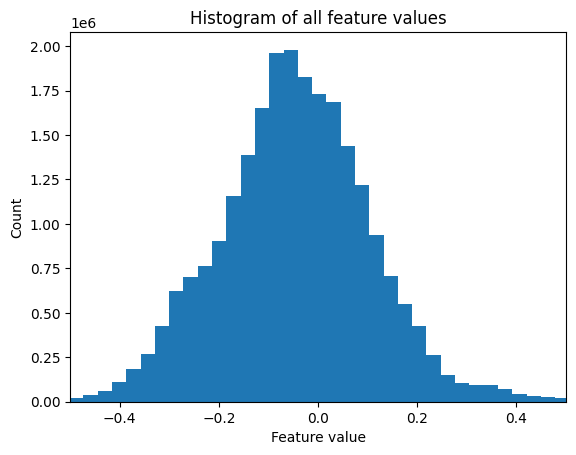

In [13]:

import matplotlib.pyplot as plt

feature_cols = [c for c in df.columns if c.startswith("feature_")]
values = df[feature_cols].values.flatten()
plt.figure()
plt.xlim(-0.5, 0.5)
plt.hist(values, bins=200)
plt.xlabel("Feature value")
plt.ylabel("Count")
plt.title("Histogram of all feature values")
plt.show()